# 03 — Training & Baseline Evaluation

**Pipeline stage 3 of 7.** Train the final LSTM at the tuned hyperparameters,
evaluate on the held-out test set, and run simple baselines (climatology,
persistence, logistic regression, random forest) for context.

**Inputs**
- Sequences from notebook 01
- `best_hps.json` from notebook 02
- `shared_config.py`

**Outputs**
- Trained model checkpoint: `best_lstm_model_*.keras`
- `baseline_metrics.json` — point estimates for AUC/AUPRC/Brier/F1
- `lstm_test_probs.npy` — per-sample predicted probabilities on the test set
  (consumed by notebook 04 for EnKF + MC dropout and by notebook 07 for ensemble)

> Source: Parts 10–12 of the original monolithic notebook.


## Setup

In [1]:
import json
import os
import numpy as np
import pandas as pd
import joblib
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report,
                             confusion_matrix, precision_recall_curve)

from shared_config import *
print_config_summary()


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load upstream artifacts

In [2]:
from lstm_utils import (build_lstm_model, class_weights_powered,
                        build_tunable_lstm)
from pipeline_utils import (
    HPsShim,
    evaluate_probability_stream,
    load_hps,
    load_sequence_artifact,
    write_json,
)

raw_seq = load_sequence_artifact(RAW_TUNED_SEQUENCES_PATH if os.path.exists(RAW_TUNED_SEQUENCES_PATH) else RAW_SEQUENCES_PATH)
enkf_seq = load_sequence_artifact(ENKF_TUNED_SEQUENCES_PATH if os.path.exists(ENKF_TUNED_SEQUENCES_PATH) else ENKF_SEQUENCES_PATH)

X_train = raw_seq["X_train"]; y_train = raw_seq["y_train"]
X_val = raw_seq["X_val"]; y_val = raw_seq["y_val"]
X_test = raw_seq["X_test"]; y_test = raw_seq["y_test"]
feature_columns = raw_seq["feature_columns"]

X_train_enkf = enkf_seq["X_train"]; y_train_enkf = enkf_seq["y_train"]
X_val_enkf = enkf_seq["X_val"]; y_val_enkf = enkf_seq["y_val"]
X_test_enkf = enkf_seq["X_test"]; y_test_enkf = enkf_seq["y_test"]
feature_columns_enkf = enkf_seq["feature_columns"]

train_df_unscaled = pd.read_parquet(TRAIN_DF_PATH)
val_df_unscaled = pd.read_parquet(VAL_DF_PATH)
test_df_unscaled = pd.read_parquet(TEST_DF_PATH)
train_df, validation_df, test_df = train_df_unscaled, val_df_unscaled, test_df_unscaled

train_scaled_df = pd.read_parquet(TRAIN_SCALED_PATH)
validation_scaled_df = pd.read_parquet(VAL_SCALED_PATH)
test_scaled_df = pd.read_parquet(TEST_SCALED_PATH)
scaler = joblib.load(SCALER_FILENAME)
final_feature_columns_used = joblib.load(FEATURE_LIST_FILENAME)

enkf_train_scaled_df = pd.read_parquet(ENKF_TRAIN_SCALED_PATH)
enkf_validation_scaled_df = pd.read_parquet(ENKF_VAL_SCALED_PATH)
enkf_test_scaled_df = pd.read_parquet(ENKF_TEST_SCALED_PATH)

raw_hps_dict = load_hps(RAW_BEST_HPS_PATH if os.path.exists(RAW_BEST_HPS_PATH) else BEST_HPS_PATH, DEFAULT_HPS_DICT)
enkf_hps_dict = load_hps(ENKF_BEST_HPS_PATH, DEFAULT_HPS_DICT)
best_hps = HPsShim(raw_hps_dict)
enkf_best_hps = HPsShim(enkf_hps_dict)

BEST_SEQ_LENGTH = raw_hps_dict["seq_length"]
BEST_BATCH_SIZE = raw_hps_dict["batch_size"]
BEST_SEQ_LEN = BEST_SEQ_LENGTH
BEST_CW_POWER = raw_hps_dict.get("cw_power", 1.0)

print(f"Raw tuned:  X_train={X_train.shape}, X_test={X_test.shape}, hps={raw_hps_dict}")
print(f"EnKF tuned: X_train={X_train_enkf.shape}, X_test={X_test_enkf.shape}, hps={enkf_hps_dict}")


Raw tuned:  X_train=(1097, 26, 26), X_test=(216, 26, 26), hps={'seq_length': 26, 'n_lstm_layers': 1, 'units_1': 32, 'units_2': 16, 'units_3': 32, 'dropout': 0.4962020568002693, 'recurrent_dropout': 0.1650470707645706, 'l2_reg': 7.245868181143025e-06, 'optimizer': 'nadam', 'learning_rate': 0.0037604364662000467, 'weight_decay': 1.3962723467364812e-05, 'batch_size': 128, 'cw_power': 0.7578785586717858}
EnKF tuned: X_train=(1097, 26, 32), X_test=(216, 26, 32), hps={'seq_length': 26, 'n_lstm_layers': 1, 'units_1': 128, 'units_2': 16, 'units_3': 32, 'dropout': 0.22086639342227468, 'recurrent_dropout': 0.05507794893806203, 'l2_reg': 3.1744361160627382e-06, 'optimizer': 'adam', 'learning_rate': 0.003346404713529923, 'weight_decay': 0.00015334259454271234, 'batch_size': 16, 'cw_power': 1.3468394464235878}


## Model builder (from Part 8, needed by training)

In [3]:
# --- Test Block ---
if __name__ == "__main__":
    print("--- Testing Model Definition (Step 7) ---")
    if 'X_train' in locals() and X_train is not None:
        input_shape_test = (X_train.shape[1], X_train.shape[2])
        print(f"Input Shape detected: {input_shape_test}")
        try:
            model_test = build_lstm_model(input_shape_test, hps=None)
            print("\nModel built successfully!")
            model_test.summary()
        except Exception as e:
            print(f"Error building model: {e}")
    else:
        print("Warning: X_train not found. Run Step 6 first to test this function.")
        print("Function 'build_lstm_model' is defined but not tested.")


--- Testing Model Definition (Step 7) ---
Input Shape detected: (26, 26)

Model built successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 26, 64)         │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

## Tunable-model builder (from Part 9, used by `train_final_model`)

In [4]:
# Sanity check
print('Class weight examples for current train target:')
y_demo = train_df[TARGET_BINARY_COL].values
for p in [0.0, 0.5, 1.0, 1.5]:
    print(f'  power={p}: {class_weights_powered(y_demo, p)}')


Class weight examples for current train target:
  power=0.0: {0: 1.0, 1: 1.0}
  power=0.5: {0: 0.8066209219350564, 1: 1.4695629910335197}
  power=1.0: {0: 0.6506373117033604, 1: 2.1596153846153845}
  power=1.5: {0: 0.5248176682115112, 1: 3.1736908440973894}


## Part 10: Model Training

This cell defines the main training function and executes it. It uses the configuration flags from Part 1 to determine whether to use class weights and whether to use default or tuned hyperparameters (from best_hps variable potentially created in Part 8). It saves the best model weights found during training.

Explanation:

1. Function train_model:
    - Takes training/validation data, input shape, configuration flags (use_class_weight), optional tuned hyperparameters (best_hps), training parameters (epochs, batch_size, patience), and paths/names for saving.
    - Builds Model: Calls build_lstm_model (from Part 7), passing best_hps if it's available (meaning tuning was done in Part 8), otherwise hp=None is passed and the function uses defaults.
    - Class Weights: If use_class_weight is True, it calculates the weights using compute_class_weight on y_train.
    - Compiles: Ensures the model is compiled with the correct learning rate (either default or from best_hps).
    - Callbacks: Sets up EarlyStopping and ModelCheckpoint. Note that ModelCheckpoint now saves the entire model in the .keras format (recommended over .h5), as we are not using the custom subclassed model in this part. The filename includes the model_type_name.
    - Fits Model: Calls model.fit(), passing the class_weight dictionary if applicable.
    - Loads Best: After training, it explicitly loads the best model saved by ModelCheckpoint to ensure the returned model represents the best validation performance.
    - Returns: The trained model object and the training history.
2. Main Execution:
    - Checks that necessary data (X_train, etc.) and configuration flags exist.
    - Determines the model_type_name based on whether tuning was performed and class weights are used (e.g., "baseline", "baseline_weighted", "tuned", "tuned_weighted").
    - Calls the train_model function with the appropriate arguments.
    - Stores the returned trained model in the trained_model variable.
    - Plots the training/validation loss and accuracy from the returned history object.
    - Sets a general model_ready_for_eval flag for the next step (Part 10: Baseline Evaluation).

After running this cell, the trained_model variable will hold the trained LSTM model (either using default or tuned hyperparameters, and potentially trained with class weights), ready for evaluation on the test set in Part 10. The best version of this model is also saved to a file.


--- Training Final Model: standalone_lstm_tuned_weighted ---
  HPs: layers=1, units=(32,16,32), dropout=0.50, l2=7e-06, opt=nadam@4e-03, batch=128, cw_power=0.76
  Class weights: {0: 0.7259258808707867, 1: 1.7607865719206541}
Epoch 1/50

Epoch 1: val_loss improved from None to 0.57829, saving model to output_refactored/best_lstm_model_standalone_lstm_tuned_weighted.keras

Epoch 1: finished saving model to output_refactored/best_lstm_model_standalone_lstm_tuned_weighted.keras
9/9 - 2s - 175ms/step - accuracy: 0.5980 - auc: 0.6423 - auprc: 0.3447 - loss: 0.6584 - precision: 0.3201 - recall: 0.6192 - val_accuracy: 0.7336 - val_auc: 0.8157 - val_auprc: 0.7626 - val_loss: 0.5783 - val_precision: 0.6698 - val_recall: 0.7634
Epoch 2/50

Epoch 2: val_loss improved from 0.57829 to 0.45432, saving model to output_refactored/best_lstm_model_standalone_lstm_tuned_weighted.keras

Epoch 2: finished saving model to output_refactored/best_lstm_model_standalone_lstm_tuned_weighted.keras
9/9 - 0s - 10m

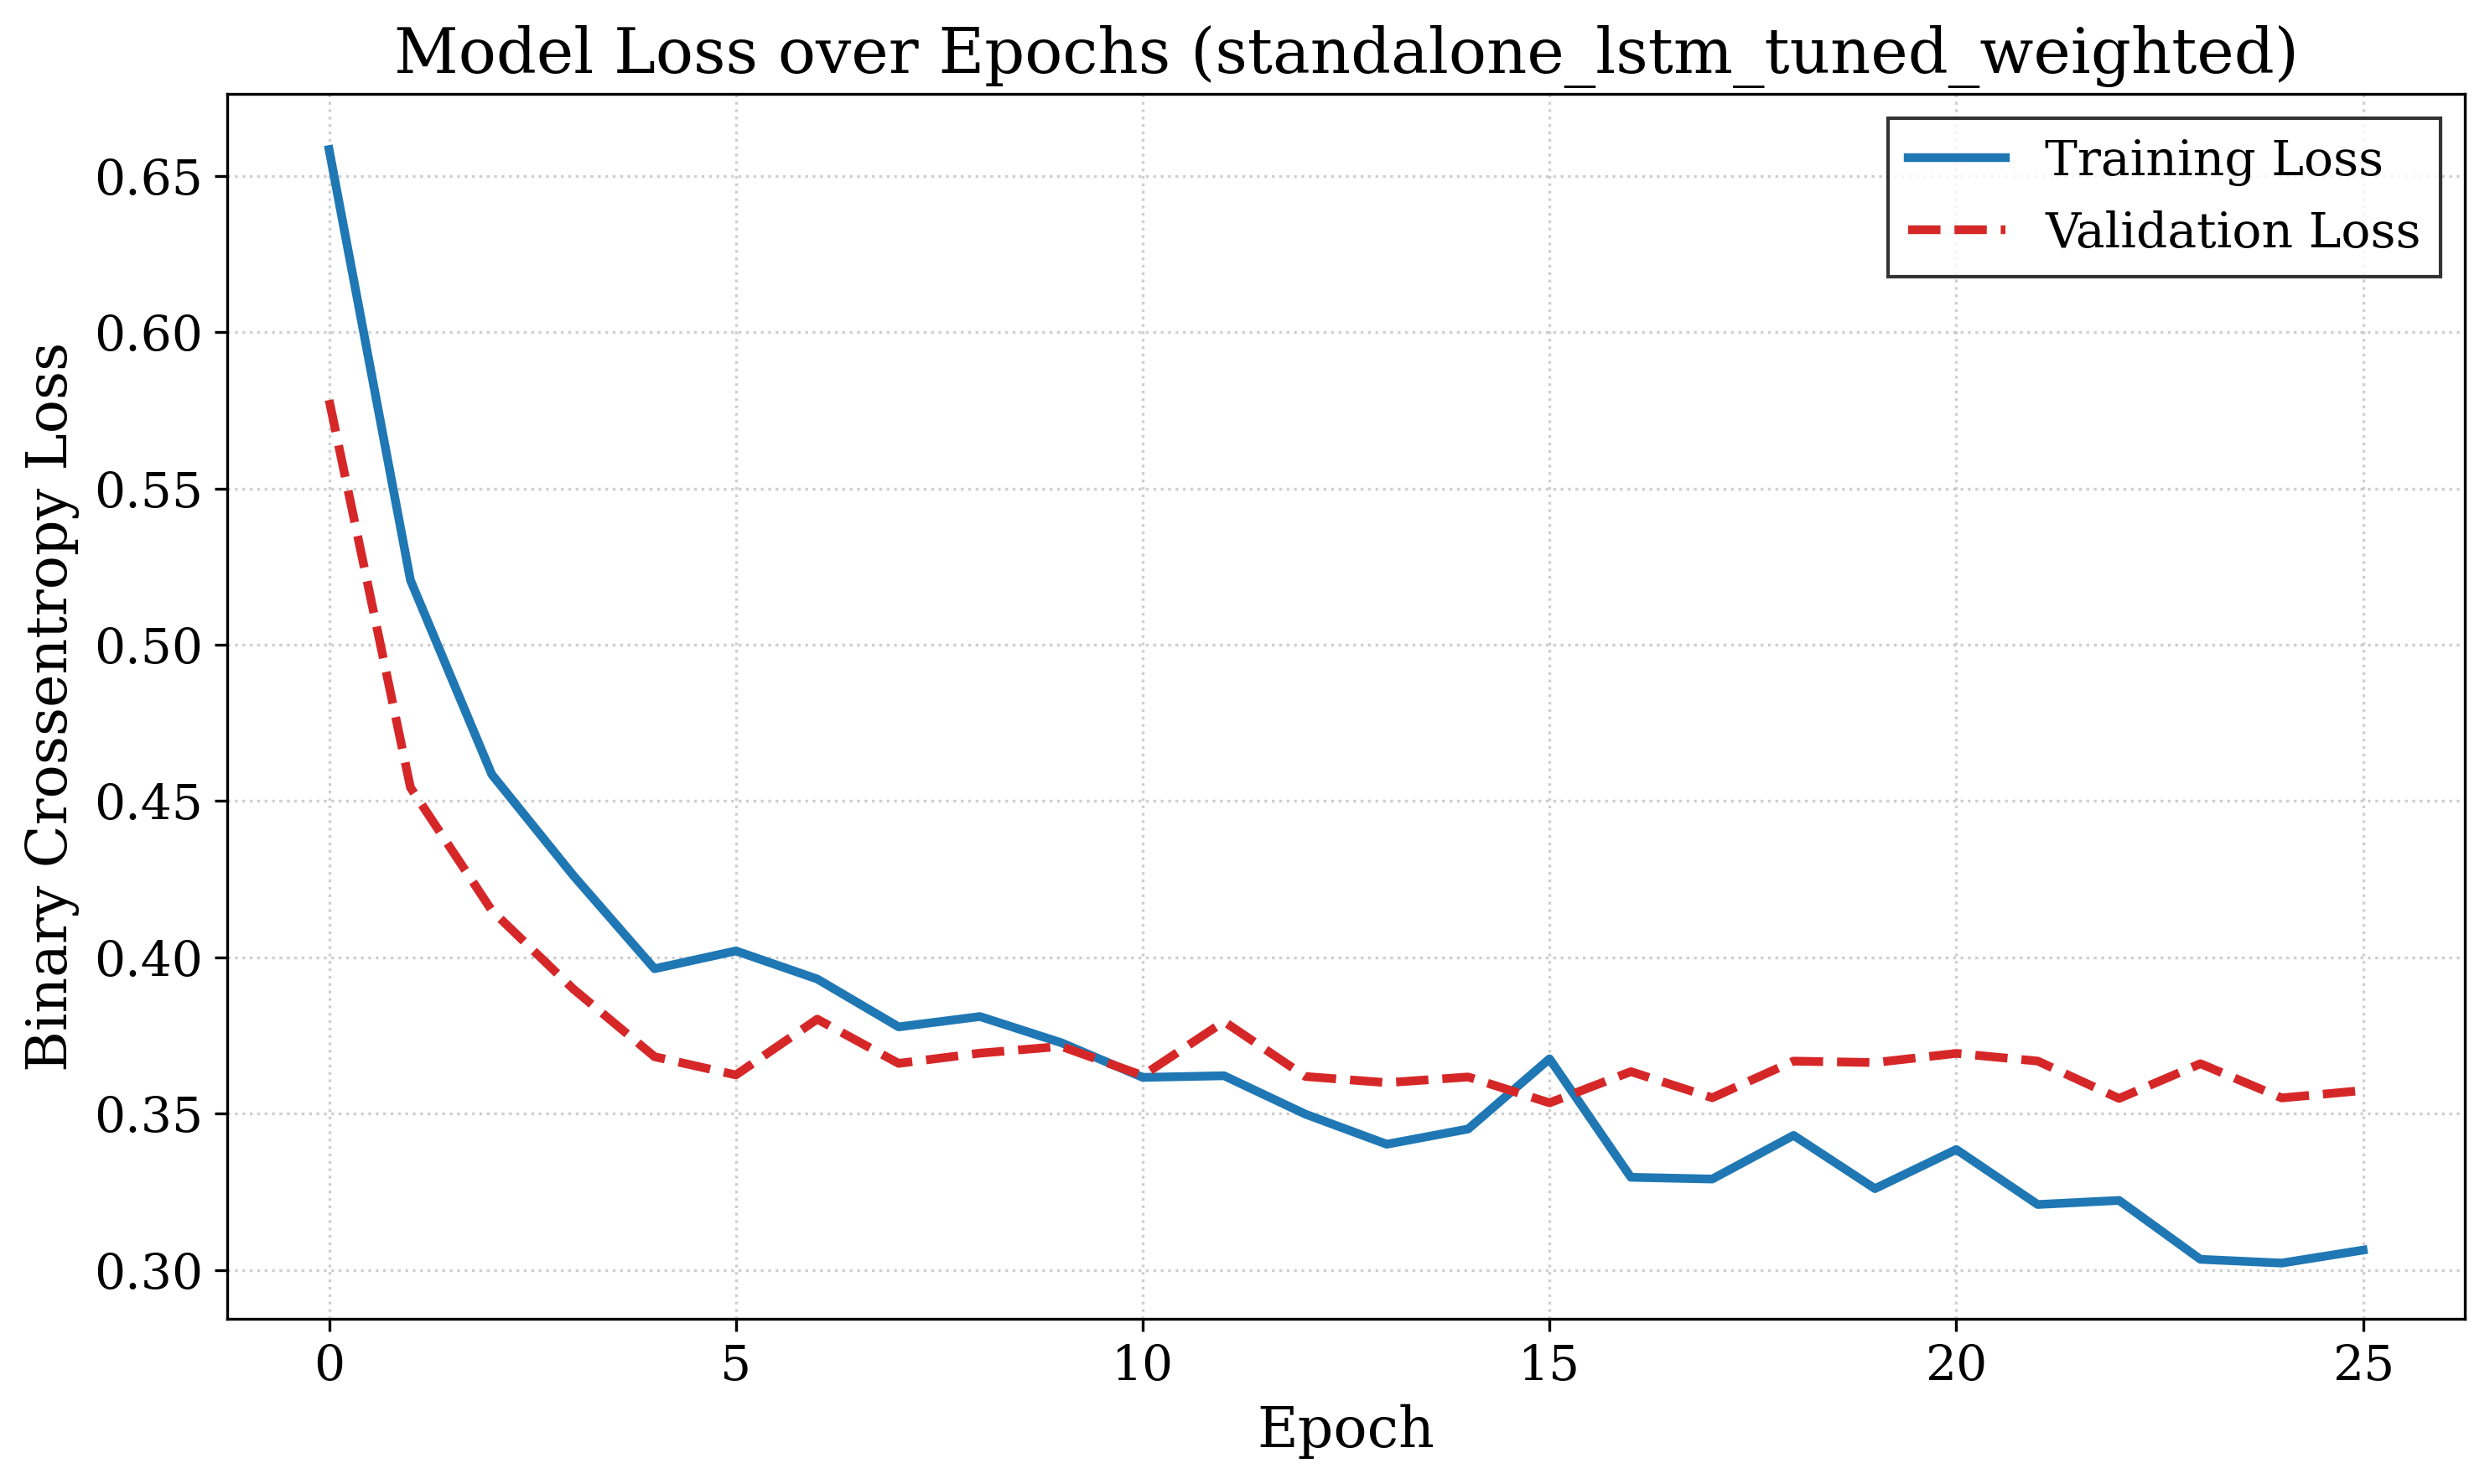

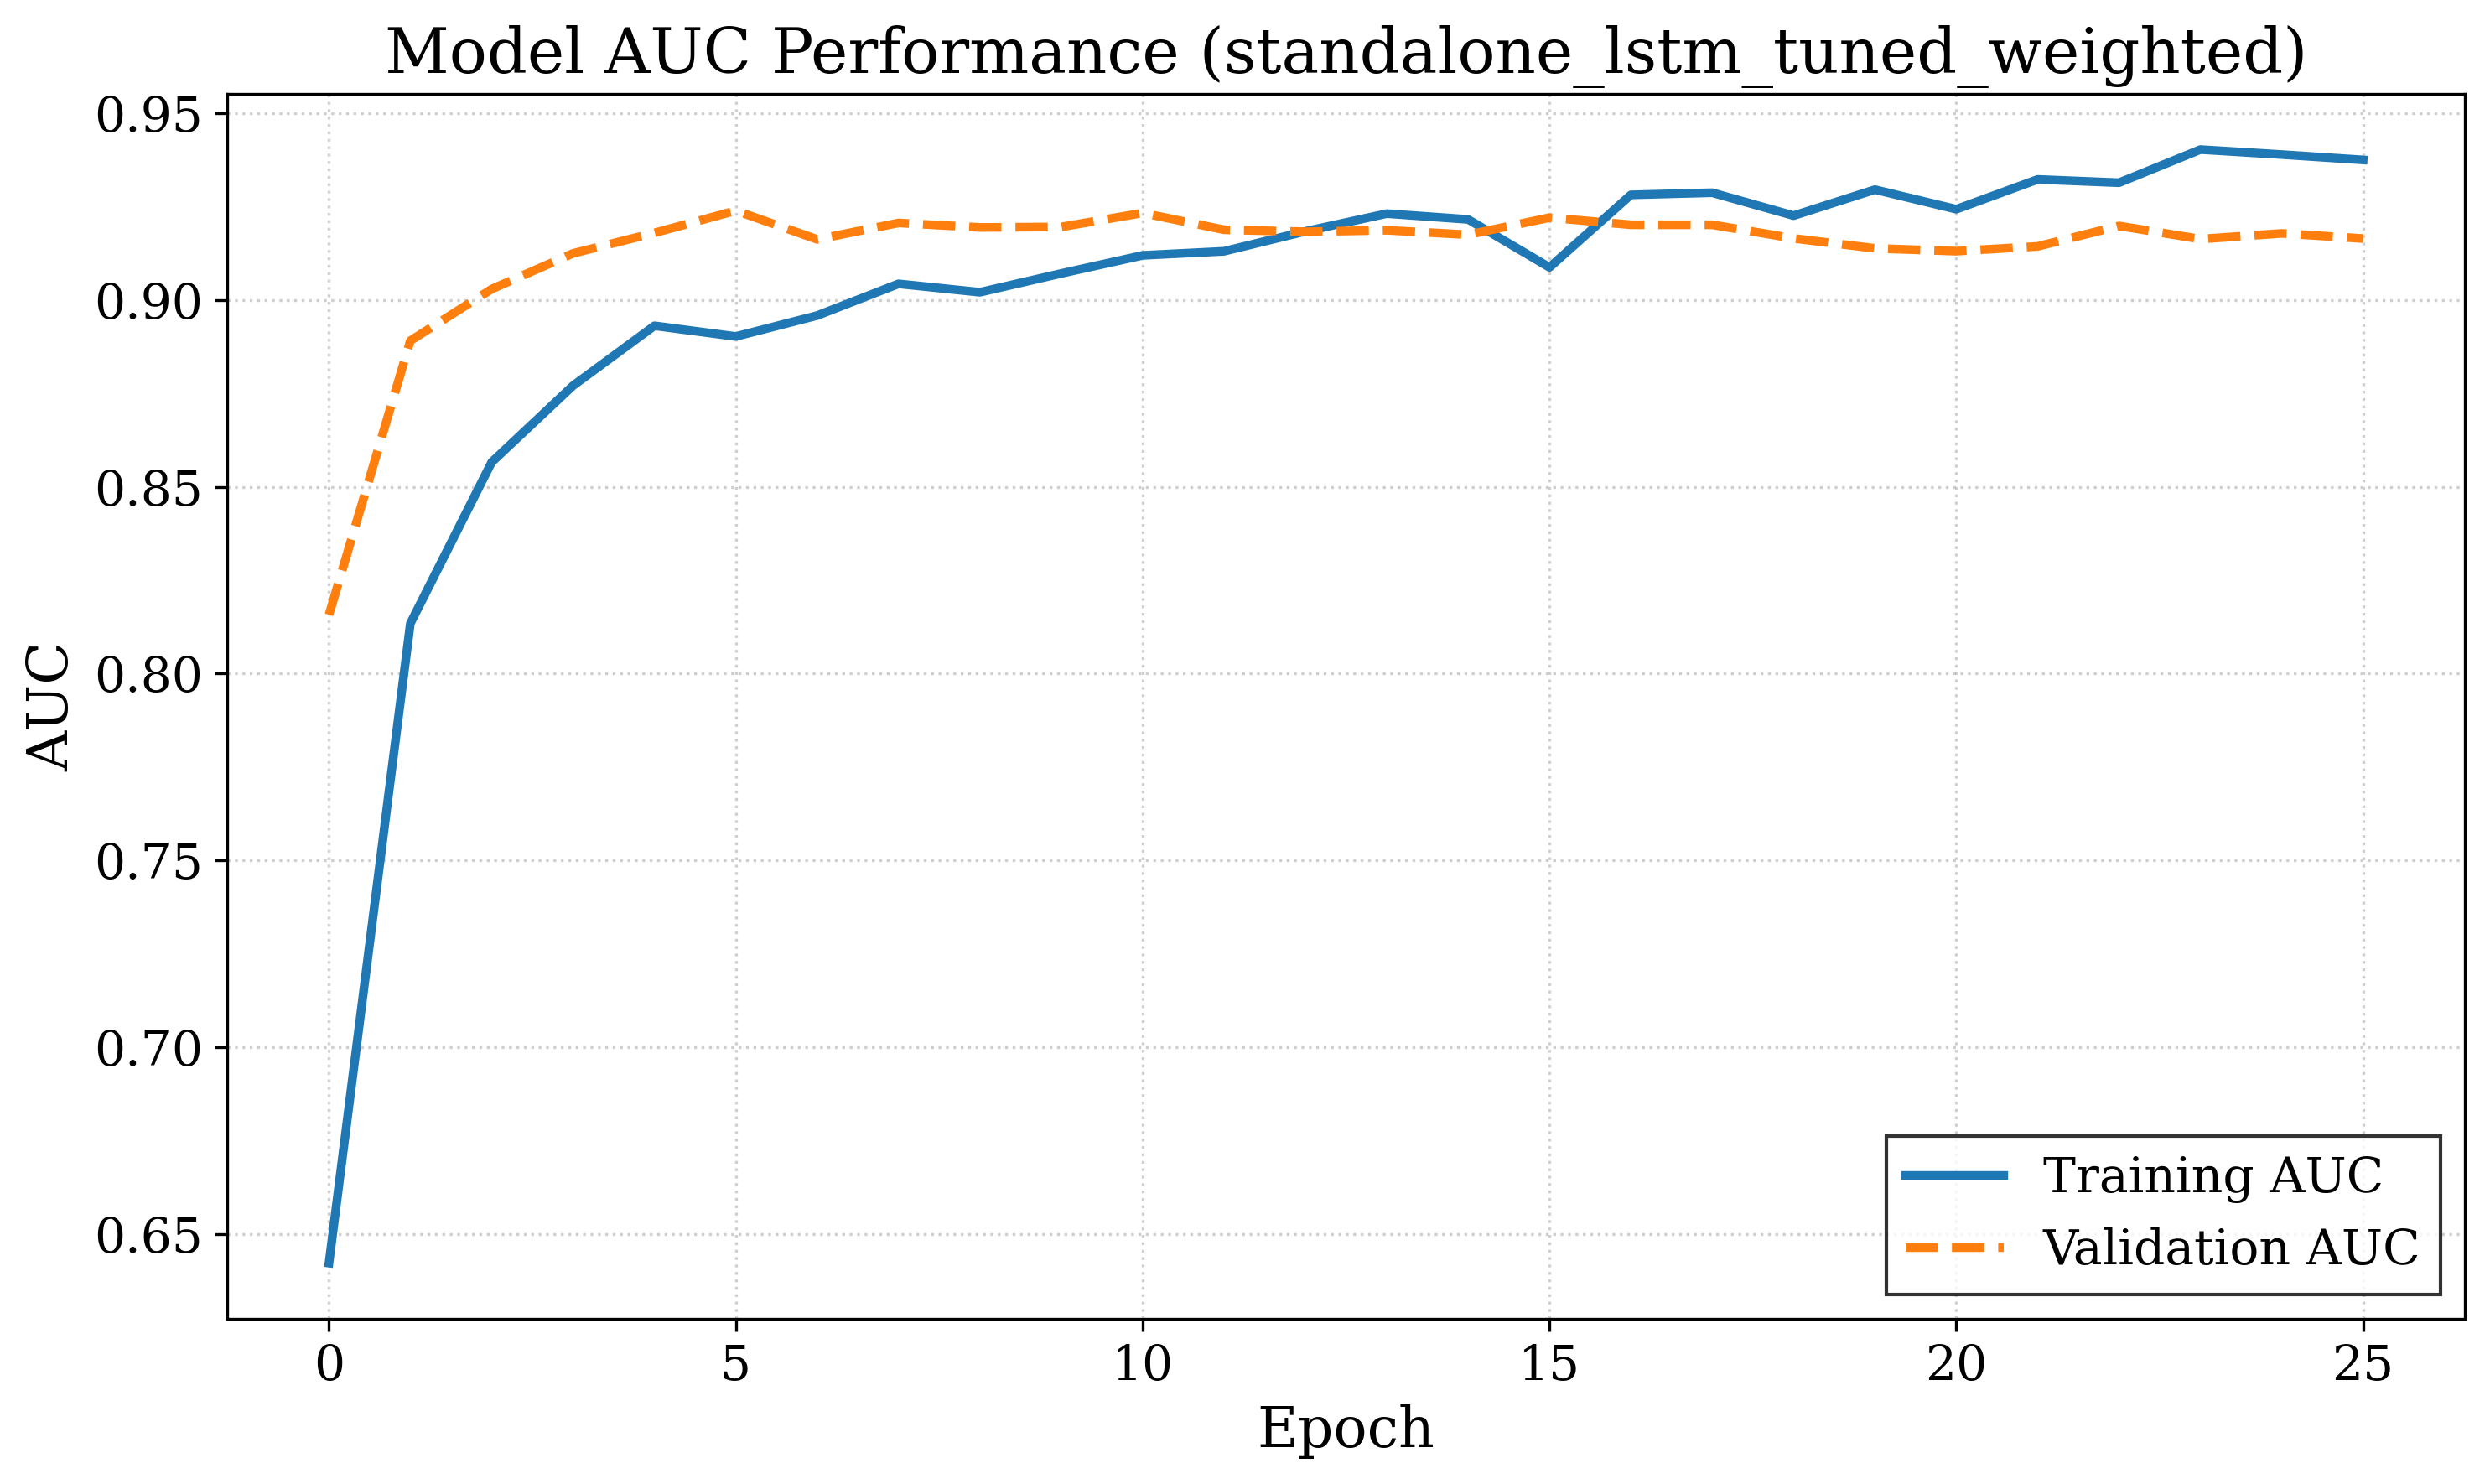


--- Training Final Model: lstm_enkf_preprocessor_tuned_weighted ---
  HPs: layers=1, units=(128,16,32), dropout=0.22, l2=3e-06, opt=adam@3e-03, batch=16, cw_power=1.35
  Class weights: {0: 0.5659645126037426, 1: 2.733063810011551}
Epoch 1/50

Epoch 1: val_loss improved from None to 0.56119, saving model to output_refactored/best_lstm_model_lstm_enkf_preprocessor_tuned_weighted.keras

Epoch 1: finished saving model to output_refactored/best_lstm_model_lstm_enkf_preprocessor_tuned_weighted.keras
69/69 - 2s - 23ms/step - accuracy: 0.6955 - auc: 0.8267 - auprc: 0.6036 - loss: 0.5444 - precision: 0.4288 - recall: 0.8577 - val_accuracy: 0.7570 - val_auc: 0.8555 - val_auprc: 0.7967 - val_loss: 0.5612 - val_precision: 0.6454 - val_recall: 0.9785
Epoch 2/50

Epoch 2: val_loss improved from 0.56119 to 0.49448, saving model to output_refactored/best_lstm_model_lstm_enkf_preprocessor_tuned_weighted.keras

Epoch 2: finished saving model to output_refactored/best_lstm_model_lstm_enkf_preprocessor_t

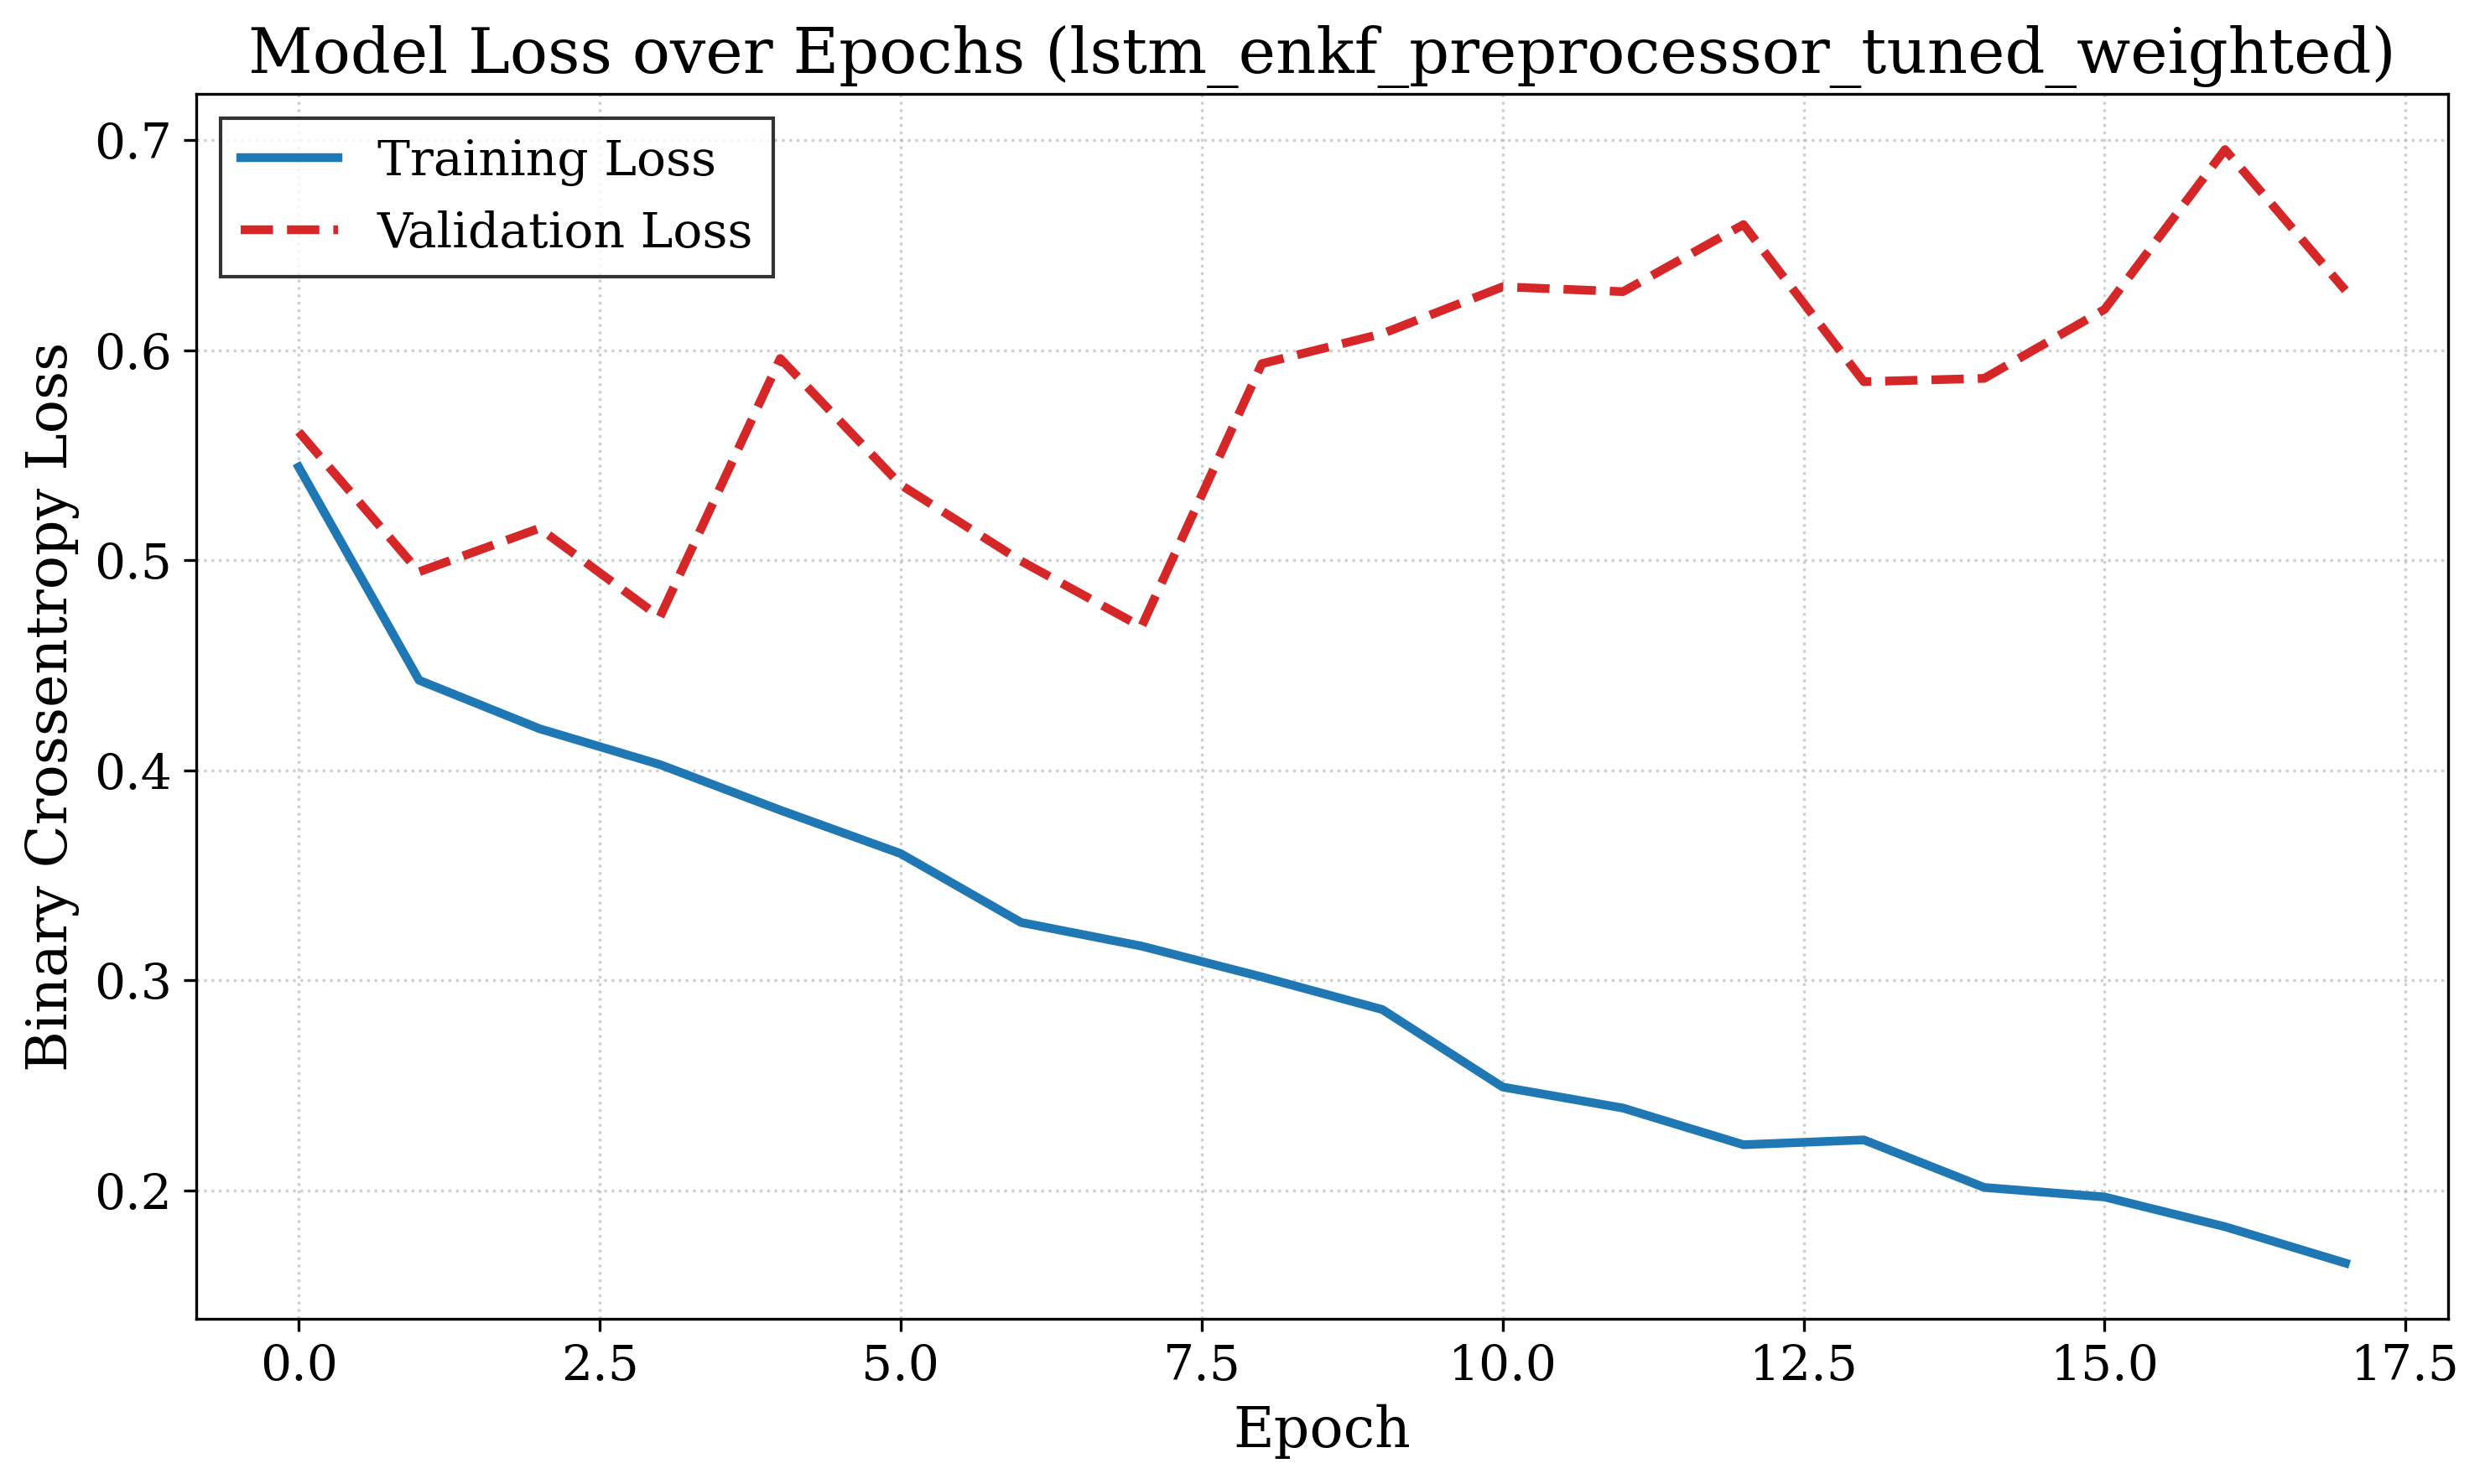

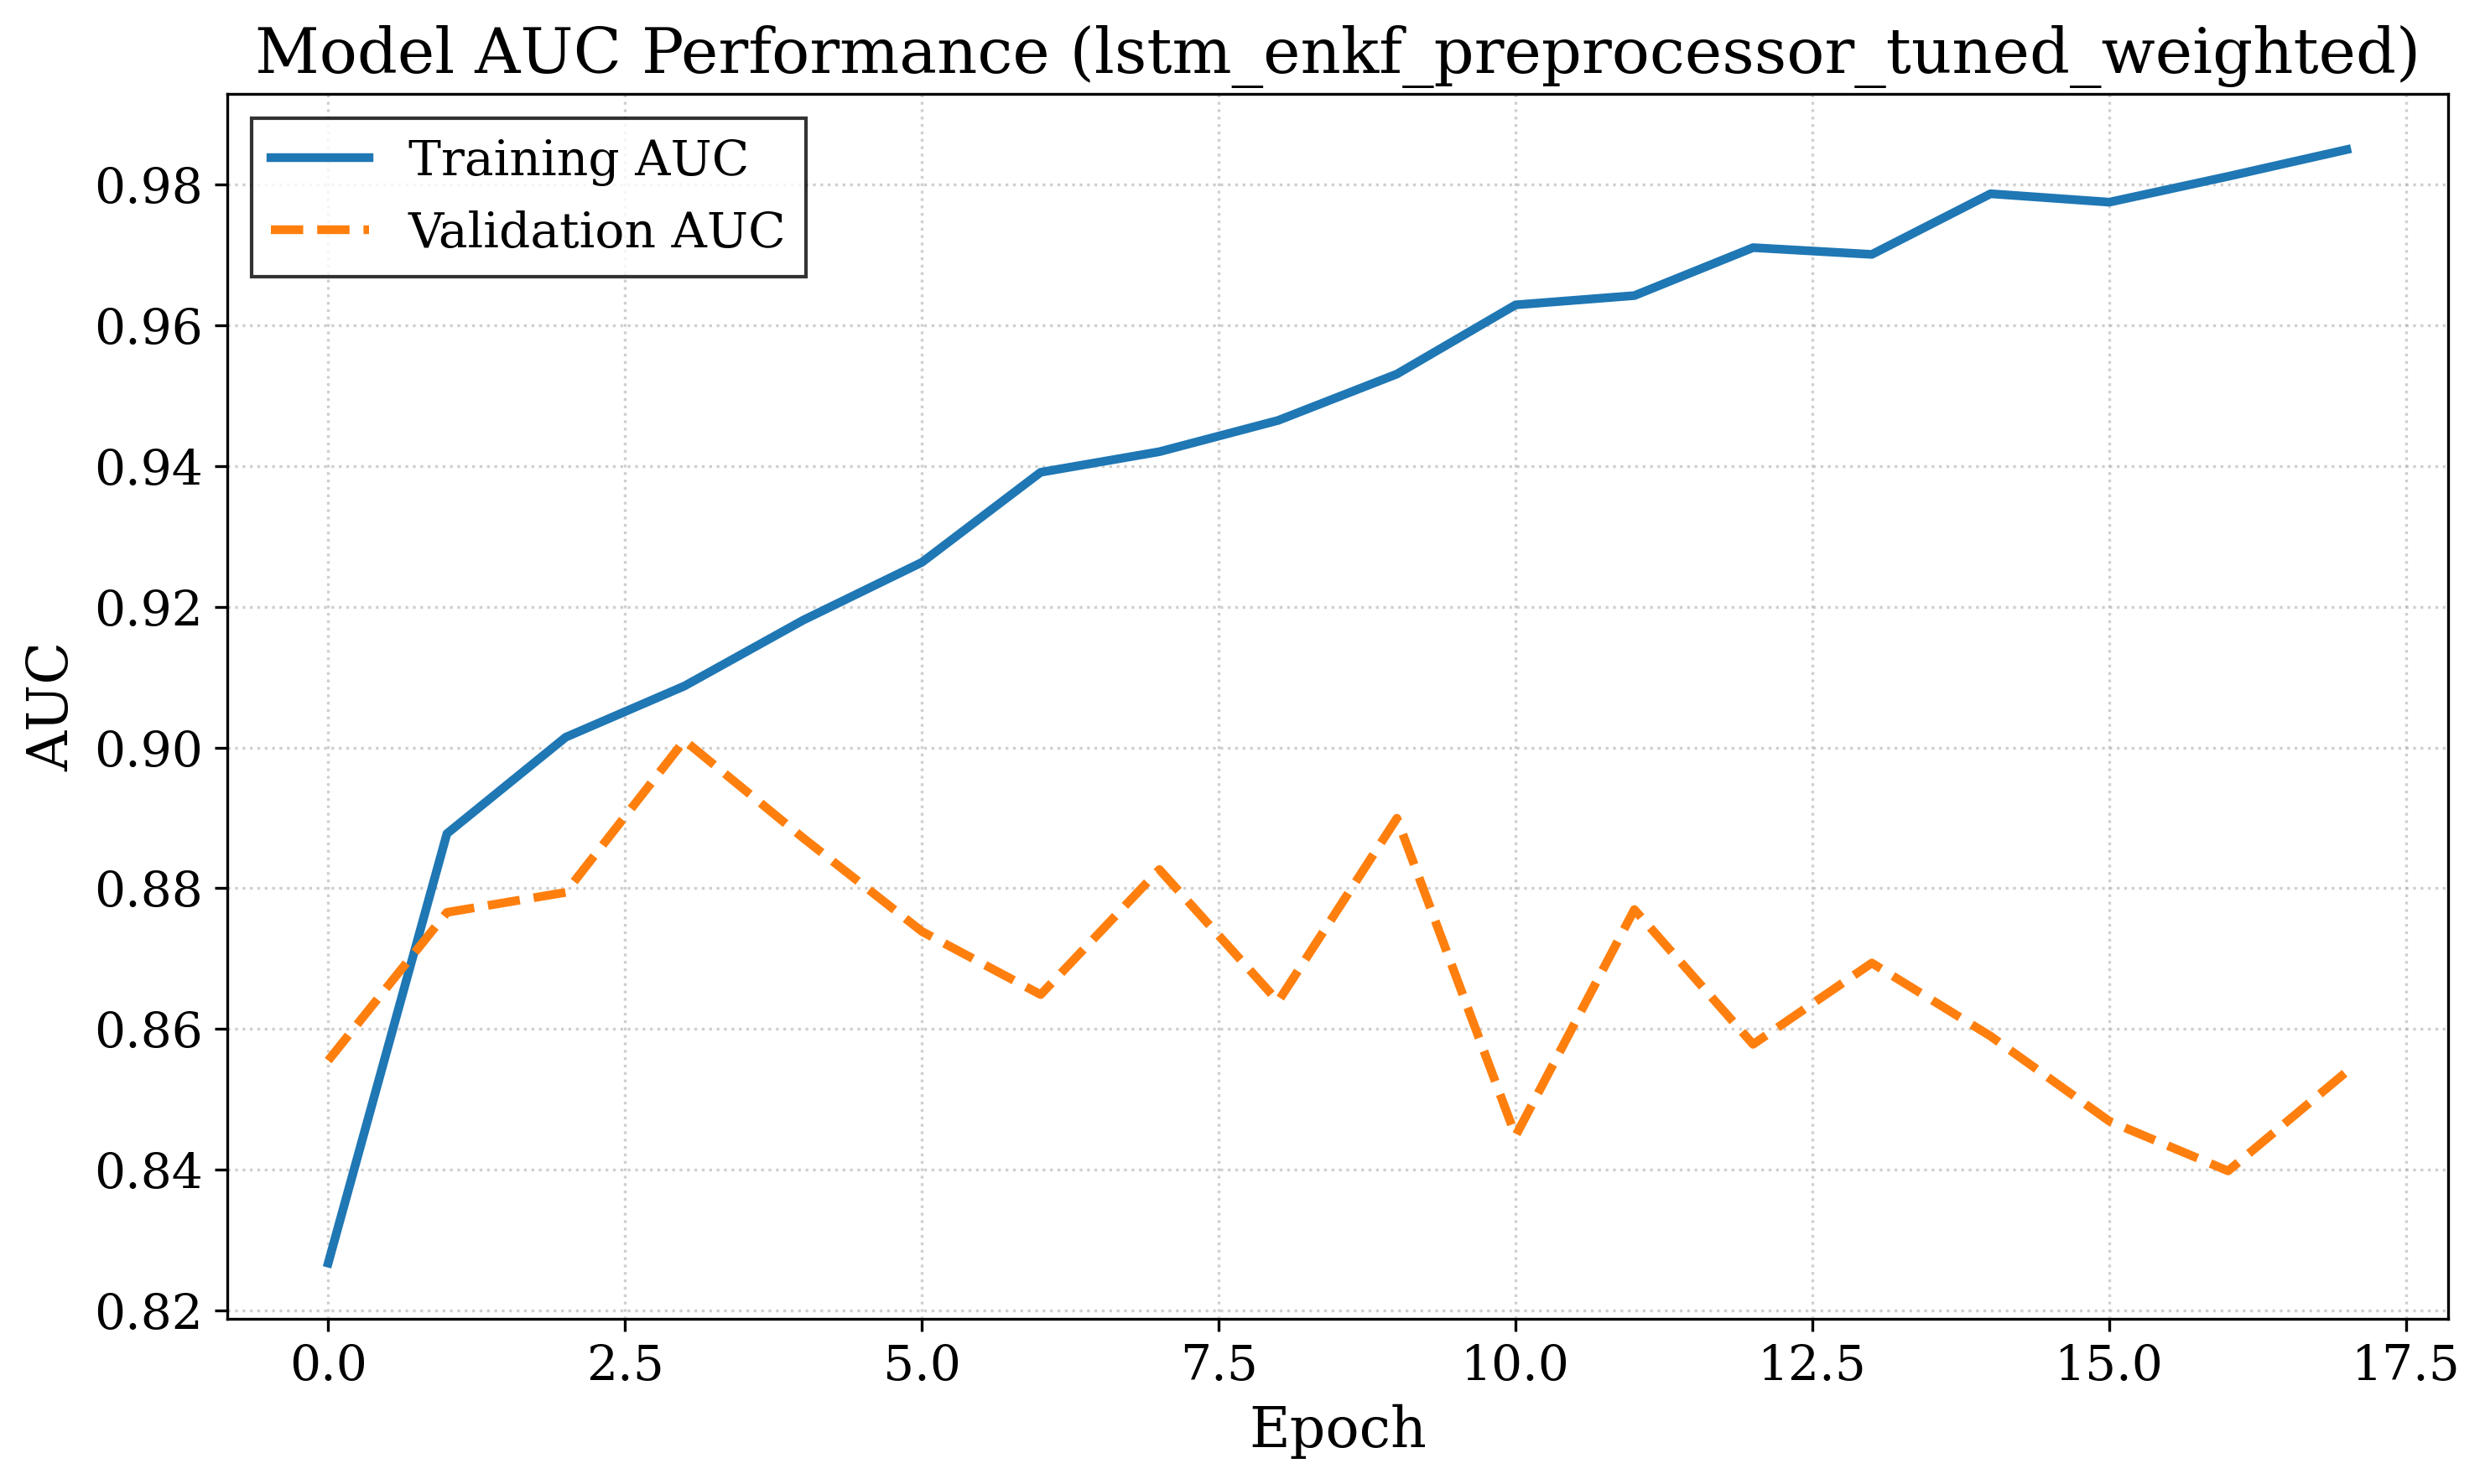

In [5]:
def train_final_model(x_train, y_train, x_val, y_val,
                      input_shape,
                      use_class_weight=False,
                      hps=None,
                      epochs=50,
                      patience=10,
                      checkpoint_path_template='output/model_{}.keras',
                      model_name='baseline'):
    """Train one final LSTM with the architecture/optimizer selected in notebook 02."""
    print(f"\n--- Training Final Model: {model_name} ---")

    h = dict(DEFAULT_HPS_DICT)
    if hps is not None:
        src = hps.to_dict() if hasattr(hps, "to_dict") else dict(hps)
        h.update(src)
    batch_size = int(h["batch_size"])
    print(
        f"  HPs: layers={h['n_lstm_layers']}, "
        f"units=({h['units_1']},{h['units_2']},{h.get('units_3', 'n/a')}), "
        f"dropout={h['dropout']:.2f}, l2={h['l2_reg']:.0e}, "
        f"opt={h['optimizer']}@{h['learning_rate']:.0e}, "
        f"batch={batch_size}, cw_power={h['cw_power']:.2f}"
    )

    model = build_tunable_lstm(input_shape, h)

    class_weights_dict = None
    if use_class_weight:
        try:
            class_weights_dict = class_weights_powered(y_train.flatten().astype(int), power=h["cw_power"])
            print(f"  Class weights: {class_weights_dict}")
        except Exception as e:
            print(f"  Error calculating weights: {e}. Continuing without class weights.")

    model_path = checkpoint_path_template.format(model_name)
    early_stopping = EarlyStopping(monitor="val_loss", patience=patience,
                                   verbose=1, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(filepath=model_path, monitor="val_loss",
                                       save_best_only=True, verbose=1)

    history = model.fit(
        np.asarray(x_train, dtype=np.float32),
        np.asarray(y_train, dtype=np.float32),
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(np.asarray(x_val, dtype=np.float32), np.asarray(y_val, dtype=np.float32)),
        callbacks=[early_stopping, model_checkpoint],
        class_weight=class_weights_dict,
        verbose=2,
    )
    print(f"--- Training finished. Best model saved to {model_path} ---")
    return model, history


def plot_training_history(history, model_name):
    import matplotlib.pyplot as plt
    os.makedirs("output", exist_ok=True)
    plt.rcdefaults()
    plt.rcParams.update({
        "font.family": "serif",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.figsize": (10, 6),
        "lines.linewidth": 2.5,
    })

    plt.figure(dpi=300)
    plt.plot(history.history["loss"], label="Training Loss", color="#1f77b4")
    plt.plot(history.history["val_loss"], label="Validation Loss", color="#d62728", linestyle="--")
    plt.title(f"Model Loss over Epochs ({model_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Crossentropy Loss")
    plt.legend(frameon=True, fancybox=False, edgecolor="black")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"output/plot_loss_{model_name}.png", bbox_inches="tight")
    plt.show()

    metric_name = "auc" if "val_auc" in history.history else "accuracy"
    plt.figure(dpi=300)
    plt.plot(history.history[metric_name], label=f"Training {metric_name.upper()}")
    plt.plot(history.history[f"val_{metric_name}"], label=f"Validation {metric_name.upper()}", linestyle="--")
    plt.title(f"Model {metric_name.upper()} Performance ({model_name})")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.upper())
    plt.legend(frameon=True, fancybox=False, edgecolor="black")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"output/plot_{metric_name}_{model_name}.png", bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    MODEL_TRAINING_JOBS = {
        "standalone_lstm": {
            "model_name": STANDALONE_LSTM_MODEL_NAME,
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test,
            "hps": raw_hps_dict,
        },
        "lstm_enkf_preprocessor": {
            "model_name": ENKF_LSTM_MODEL_NAME,
            "X_train": X_train_enkf, "y_train": y_train_enkf,
            "X_val": X_val_enkf, "y_val": y_val_enkf,
            "X_test": X_test_enkf, "y_test": y_test_enkf,
            "hps": enkf_hps_dict,
        },
    }

    trained_models = {}
    training_histories = {}
    for job_key, job in MODEL_TRAINING_JOBS.items():
        model, hist = train_final_model(
            job["X_train"], job["y_train"], job["X_val"], job["y_val"],
            input_shape=(job["X_train"].shape[1], job["X_train"].shape[2]),
            use_class_weight=USE_CLASS_WEIGHT,
            hps=job["hps"],
            epochs=TRAIN_EPOCHS,
            patience=TRAIN_PATIENCE,
            checkpoint_path_template=MODEL_CHECKPOINT_TEMPLATE,
            model_name=job["model_name"],
        )
        trained_models[job_key] = model
        training_histories[job_key] = hist
        plot_training_history(hist, job["model_name"])

    trained_model = trained_models["standalone_lstm"]
    enkf_trained_model = trained_models["lstm_enkf_preprocessor"]
    training_history = training_histories["standalone_lstm"]
    model_ready_for_eval = True


## Part 11: Baseline Evaluation

This cell defines the evaluation function and applies it to the model trained in Part 9 (trained_model). It calculates and prints various classification metrics, plots the confusion matrix and predictions over time, and assesses the model's ability to predict bloom onsets.

Explanation:

1. Function evaluate_model:
    - Takes the model object, test data (x_test, y_test), the unscaled test dataframe test_df_unscaled (needed for correct timestamps), sequence length, forecast horizon, and a model_name string as input.
    - Predictions: Runs model.predict(x_test) to get probabilities. Converts probabilities to class predictions using a 0.5 threshold.
    - Metrics Calculation: Uses scikit-learn functions to calculate accuracy, precision, recall, F1-score (for the positive class '1'), AUC-ROC (using probabilities), and Brier score (using probabilities). Includes error handling for AUC calculation if only one class is present in y_test.
    - Reporting: Prints a formatted summary of the metrics and the full classification report.\
    - Confusion Matrix: Calculates and plots the confusion matrix using seaborn for better visualization.
    - Time Series Plot: Determines the correct start index in the test_df_unscaled index based on sequence length and forecast horizon to align the predictions (y_pred_prob) with the actual dates. Plots actuals vs. predicted probabilities. Includes checks for length mismatches.
    - Onset Analysis: Implements the logic to find actual bloom onsets (0 -> 1 transitions in y_test) and checks if the model predicted a bloom (class 1) either in the week before the onset or during the onset week. Reports the hit rate.
2. Main Execution:
    - Checks if the necessary variables (trained_model, X_test, y_test, test_df, etc.) exist from previous steps.
    - Calls the evaluate_model function, passing the required arguments. Uses the model_type_trained variable (set at the end of Part 9) to label the output correctly.

After running this cell, you will have a comprehensive evaluation of the model trained in Part 9, including standard metrics, plots, and the crucial bloom onset performance assessment. This provides the baseline against which the EnKF-enhanced model (Part 12/13) will be compared.      


=== Evaluating Model: LSTM_Baseline ===
1. Generating predictions...

Optimal Decision Threshold: 0.6580 (Max F1: 0.8553)

2. Performance Metrics (at Optimal Threshold):
Metric calculation error: name 'accuracy_score' is not defined
Saved: output/confusion_matrix_LSTM_Baseline.png


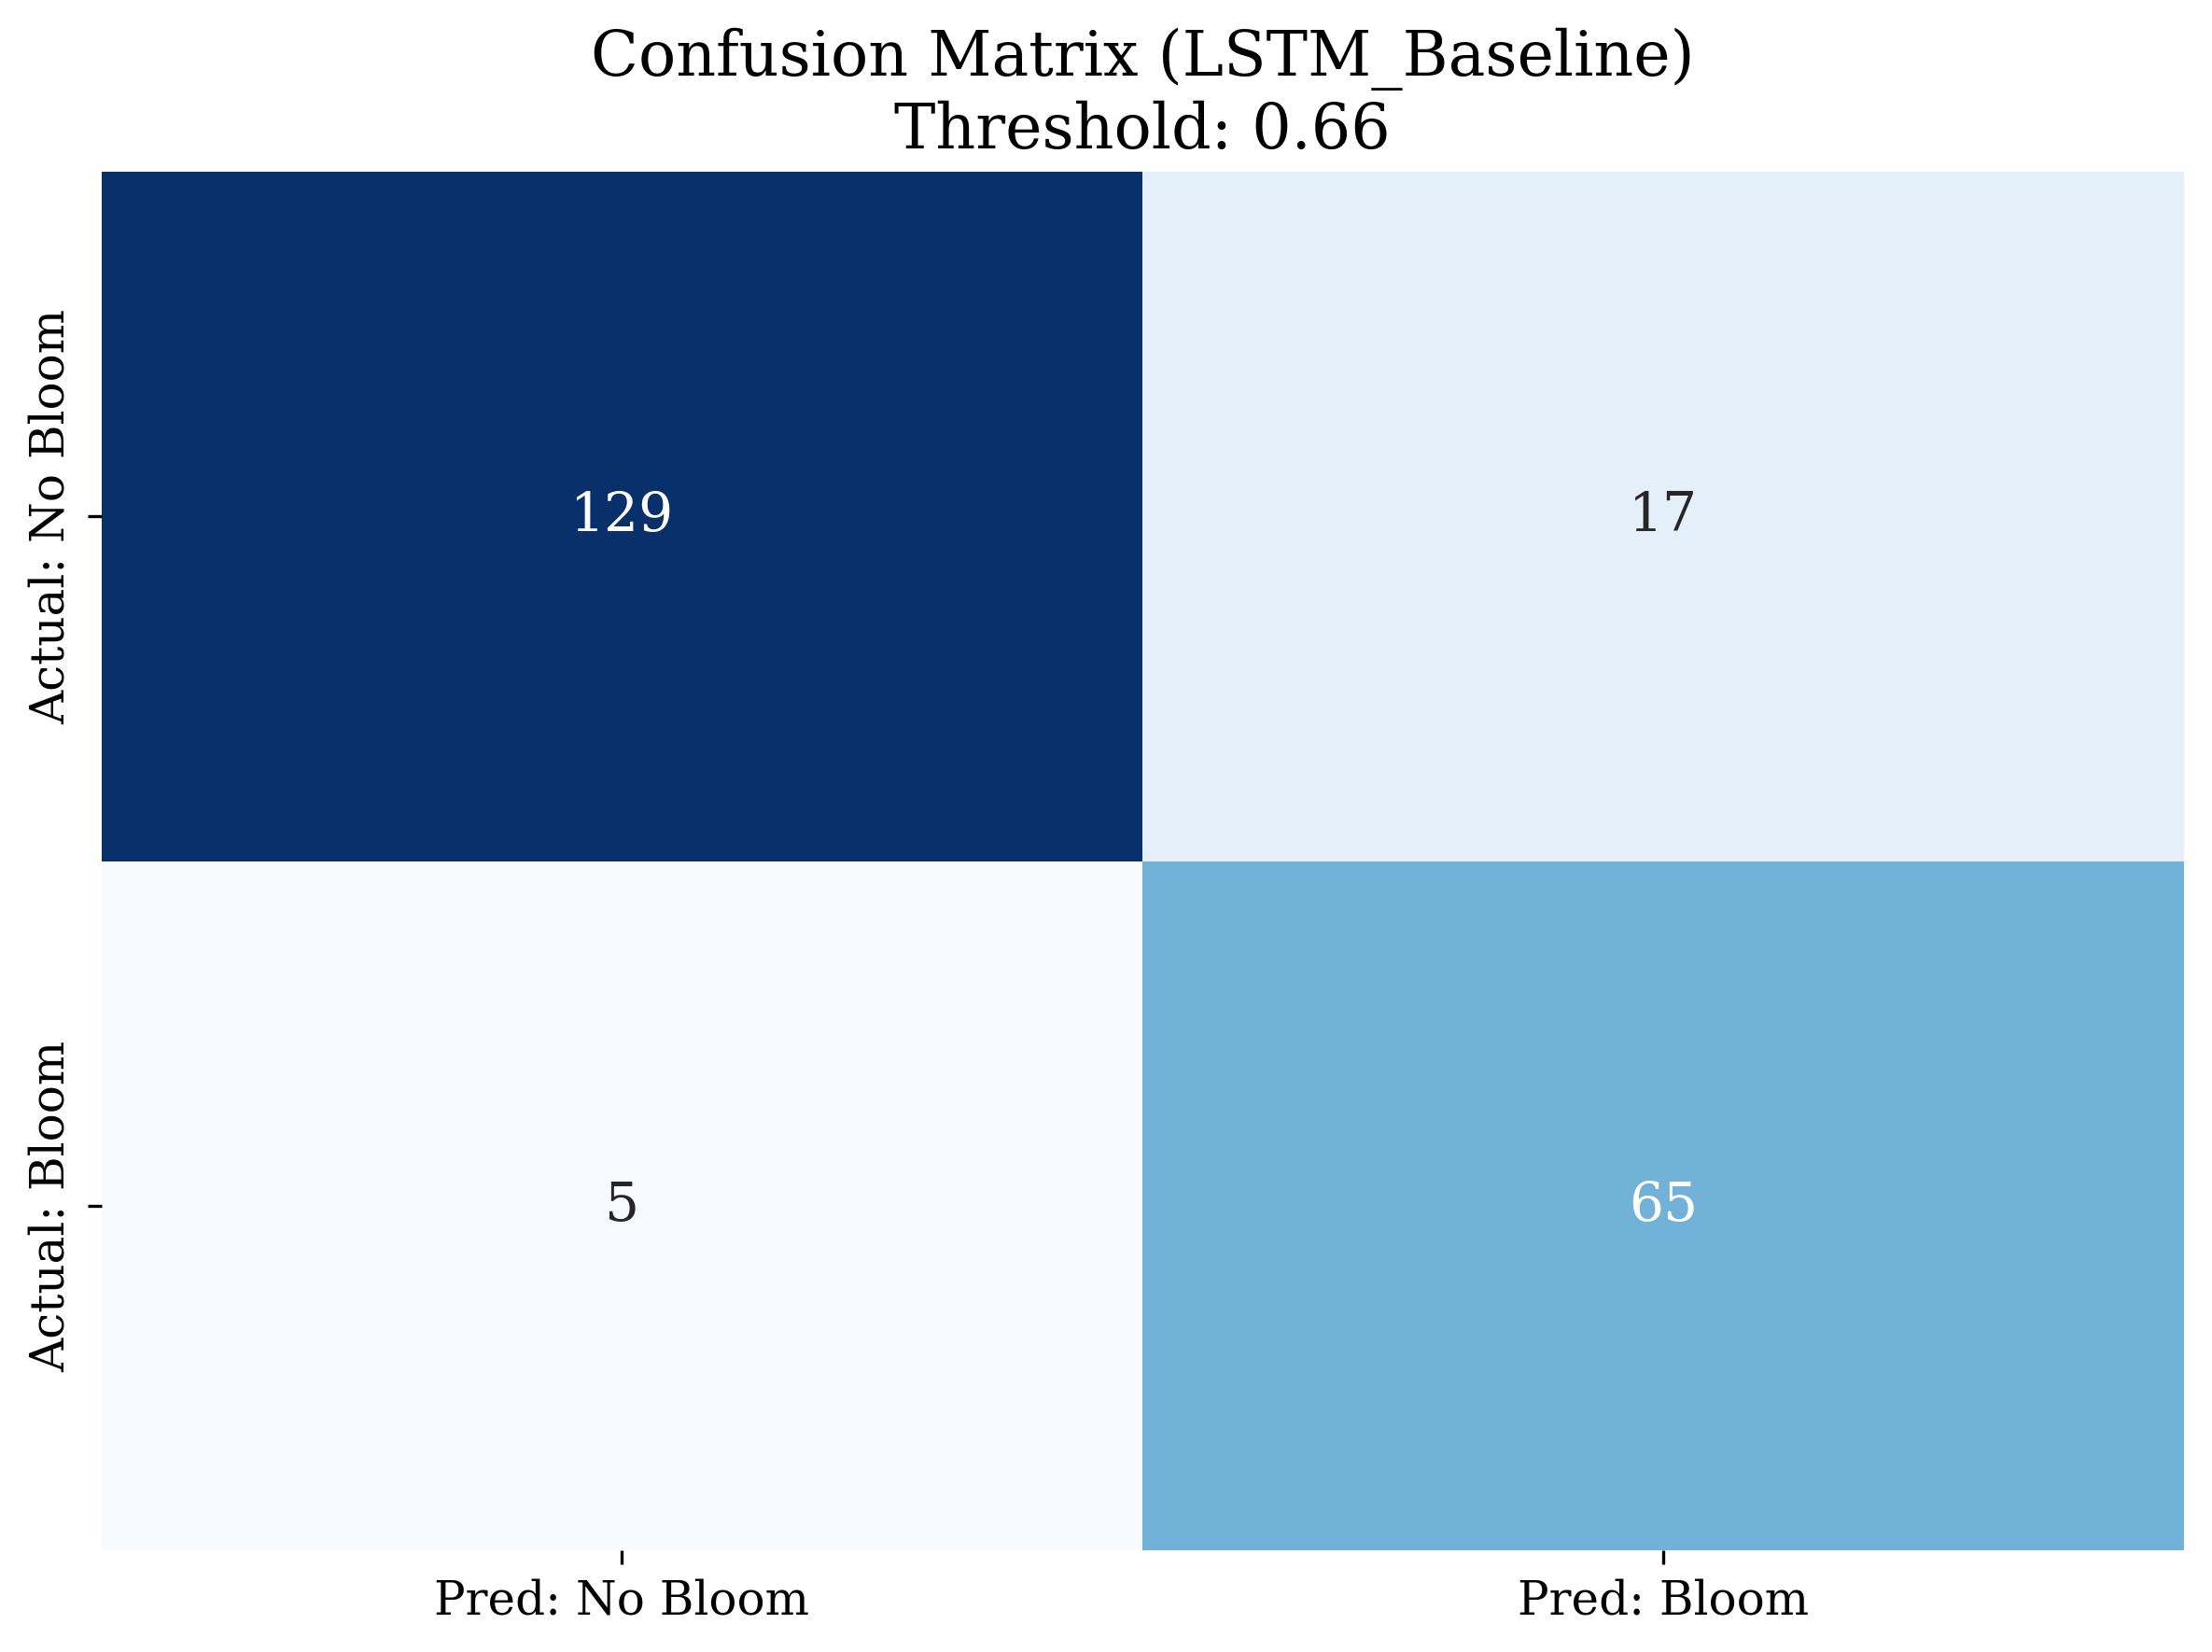


3. Plotting Time Series Predictions...
Saved: output/timeseries_preds_LSTM_Baseline.png


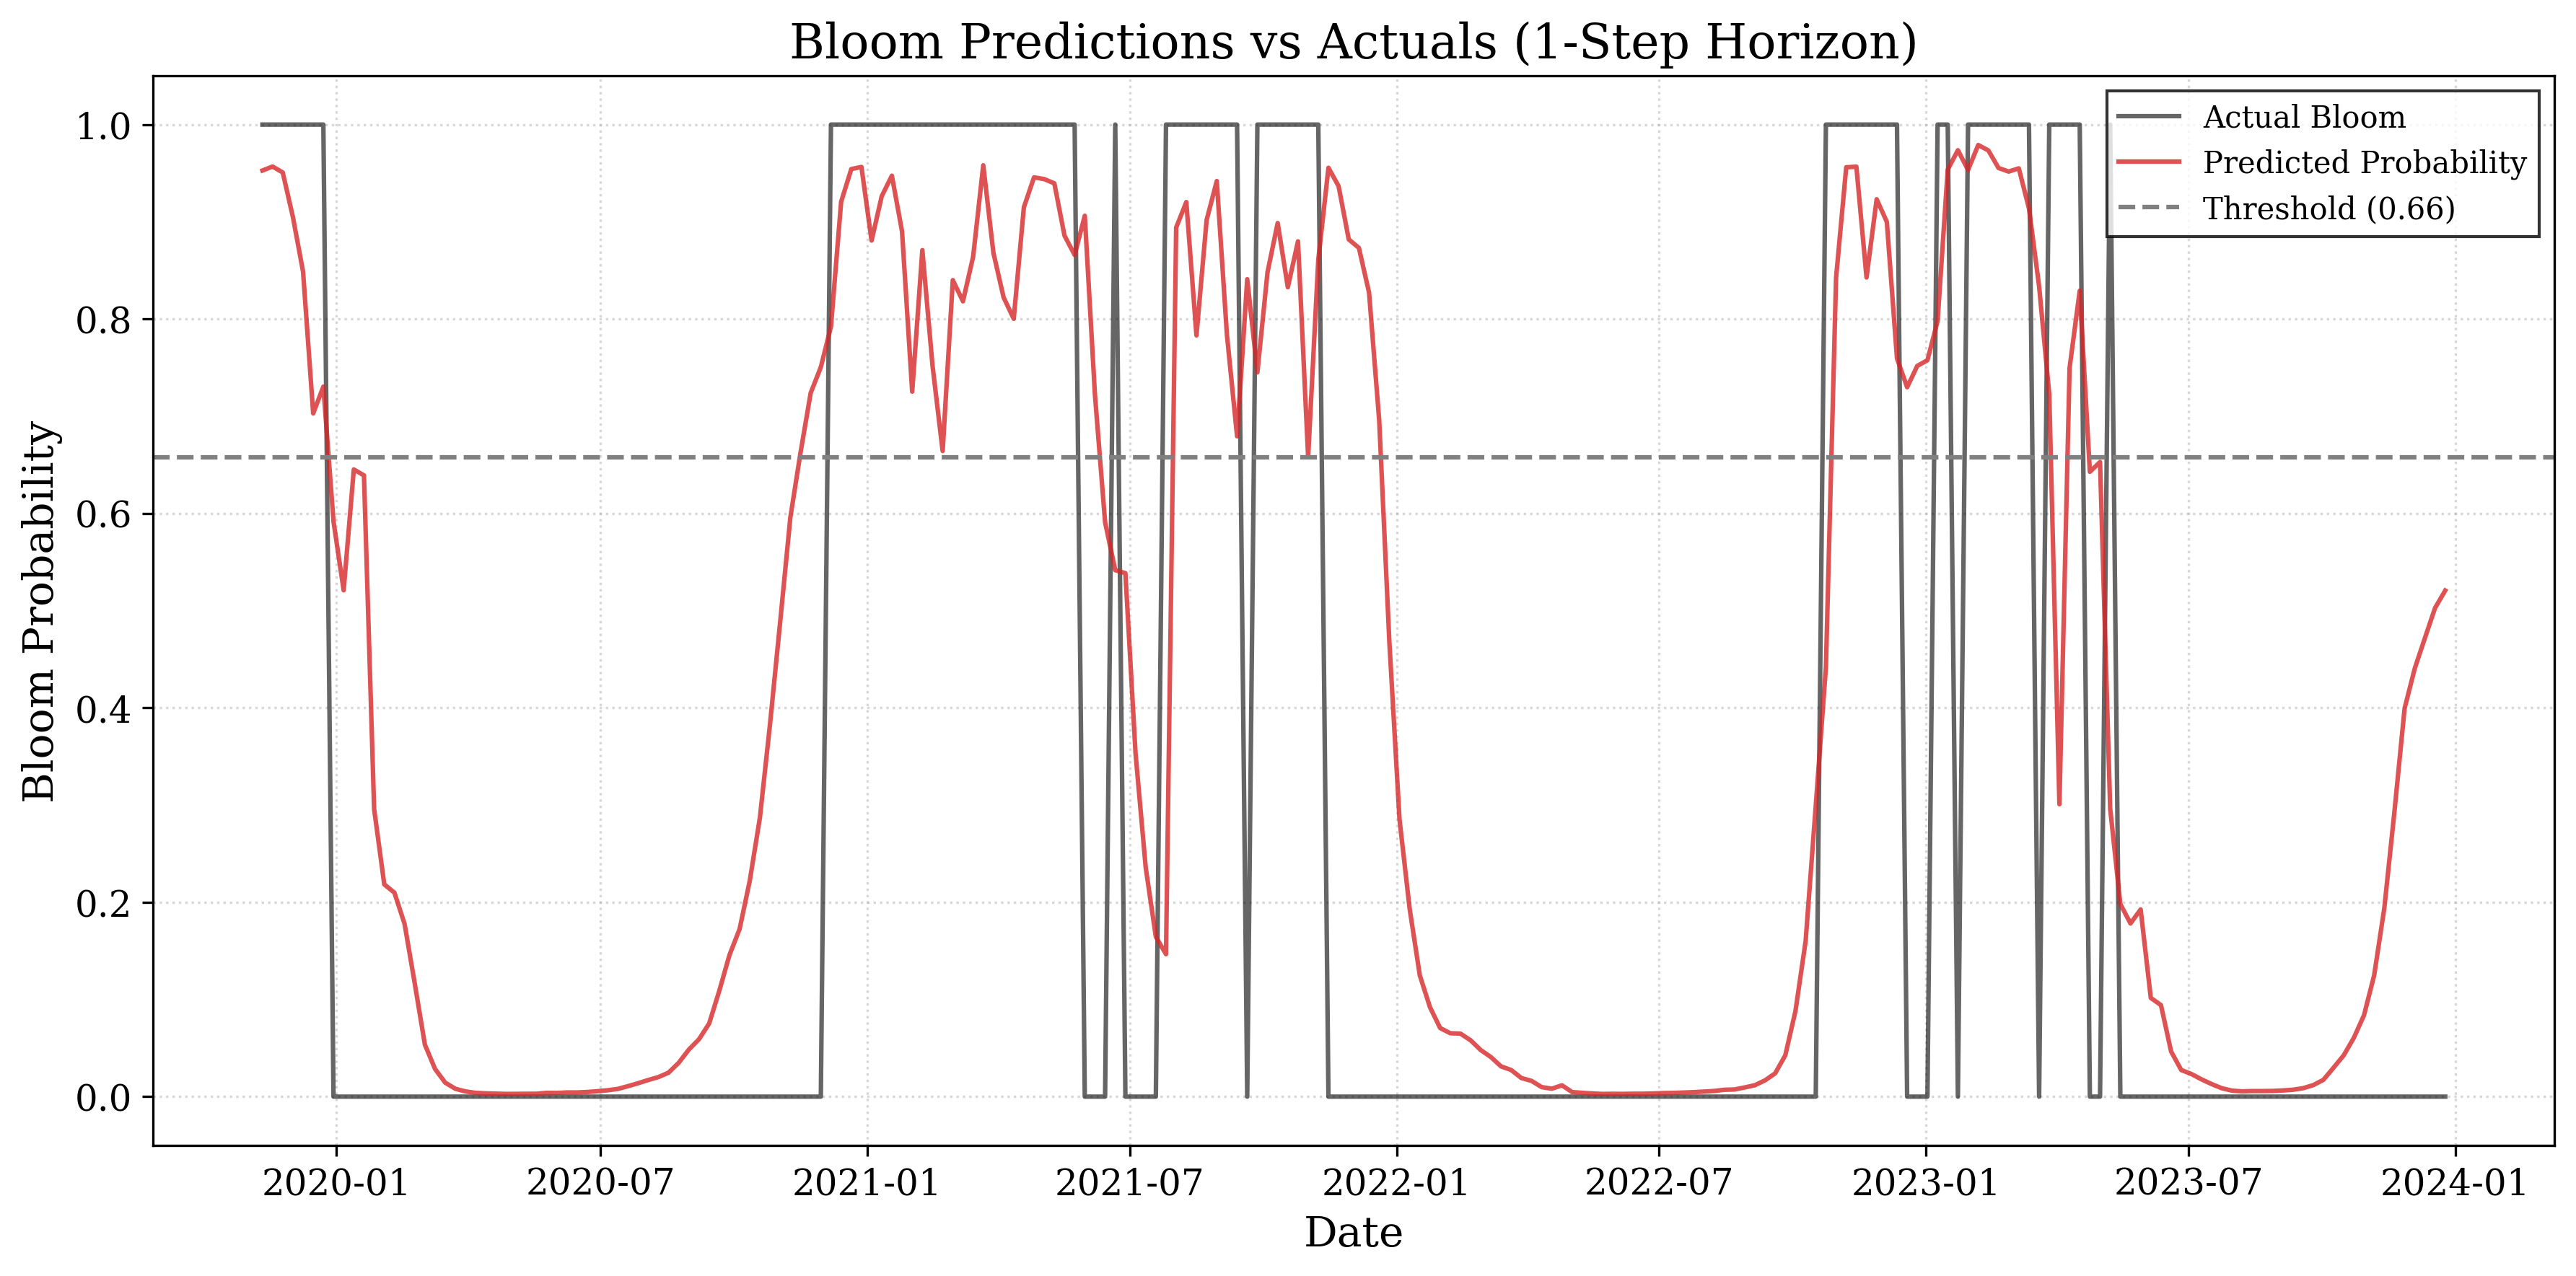


4. Bloom Onset Analysis (Did we catch the start?)
  Total Onsets: 9
  Caught Early/On-Time: 5 (55.6%)
  Caught 1-Week Late:   2
  Missed Completely:    2


In [6]:
from matplotlib import pyplot as plt
import seaborn as sns

def evaluate_model(model, x_test, y_test, test_df_unscaled,
                   seq_len, forecast_horizon, model_name="Model"):
    """
    Evaluates model with Optimal Threshold detection and Publication Plots.
    Saves figures to 'output/' folder.
    """
    if model is None or x_test is None or y_test is None:
        print("Error: Missing model or test data.")
        return

    # Ensure output directory exists
    os.makedirs('output', exist_ok=True)

    print(f"\n=== Evaluating Model: {model_name} ===")

    # 1. Generate Probabilities
    print("1. Generating predictions...")
    try:
        # Get raw probabilities (0.0 to 1.0)
        y_pred_prob = model.predict(x_test, verbose=0)
        y_test_eval = y_test.reshape(-1, 1) # Ensure 2D shape
    except Exception as e:
        print(f"Error during prediction: {e}")
        return

    # 2. Find Optimal Threshold (Fixed Math)
    # ------------------------------------------------------
    precision, recall, thresholds = precision_recall_curve(y_test_eval, y_pred_prob)

    # Calculate F-Score safely (avoid 0/0 division)
    numerator = 2 * precision * recall
    denominator = precision + recall
    with np.errstate(divide='ignore', invalid='ignore'):
        fscore = np.divide(numerator, denominator)
    fscore = np.nan_to_num(fscore) # Replace NaNs with 0

    # Locate the index of the largest F score
    ix = np.argmax(fscore)

    # Safety check for index bounds
    if ix >= len(thresholds):
        best_thresh = thresholds[-1]
    else:
        best_thresh = thresholds[ix]

    print(f"\nOptimal Decision Threshold: {best_thresh:.4f} (Max F1: {fscore[ix]:.4f})")
    # ------------------------------------------------------

    # Apply Best Threshold
    y_pred_class = (y_pred_prob >= best_thresh).astype(int)

    # 3. Calculate Metrics (at Best Threshold)
    print("\n2. Performance Metrics (at Optimal Threshold):")
    try:
        acc = accuracy_score(y_test_eval, y_pred_class)
        prec = precision_score(y_test_eval, y_pred_class, zero_division=0)
        rec = recall_score(y_test_eval, y_pred_class, zero_division=0)
        f1 = f1_score(y_test_eval, y_pred_class, zero_division=0)
        auc = roc_auc_score(y_test_eval, y_pred_prob)
        brier = brier_score_loss(y_test_eval, y_pred_prob)

        print(f"  Accuracy:    {acc:.4f}")
        print(f"  Precision:   {prec:.4f}")
        print(f"  Recall:      {rec:.4f}")
        print(f"  F1-Score:    {f1:.4f}")
        print(f"  AUC-ROC:     {auc:.4f}")
        print(f"  Brier Score: {brier:.4f}")

        print(f"\nClassification Report:\n{classification_report(y_test_eval, y_pred_class, target_names=['No Bloom', 'Bloom'])}")

    except Exception as e:
        print(f"Metric calculation error: {e}")

    # 4. Publication-Quality Plots
    # ----------------------------
    # Apply Academic Style
    plt.rcdefaults()
    params = {'font.family': 'serif', 'figure.figsize': (8, 6), 'figure.dpi': 300,
              'axes.labelsize': 14, 'axes.titlesize': 16, 'xtick.labelsize': 12, 'ytick.labelsize': 12}
    plt.rcParams.update(params)

    # --- Plot A: Confusion Matrix ---
    try:
        cm = confusion_matrix(y_test_eval, y_pred_class)
        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Pred: No Bloom', 'Pred: Bloom'],
                    yticklabels=['Actual: No Bloom', 'Actual: Bloom'],
                    annot_kws={"size": 14})
        plt.title(f'Confusion Matrix ({model_name})\nThreshold: {best_thresh:.2f}')
        plt.tight_layout()

        # SAVE FIGURE
        save_path = f"output/confusion_matrix_{model_name}.png"
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.show()
    except Exception as e:
        print(f"CM Plot Error: {e}")

    # --- Plot B: Time Series Predictions ---
    print(f"\n3. Plotting Time Series Predictions...")
    start_idx = seq_len + forecast_horizon - 1
    num_preds = len(y_pred_prob)

    if start_idx + num_preds <= len(test_df_unscaled):
        dates = test_df_unscaled.index[start_idx : start_idx + num_preds]

        plt.figure(figsize=(12, 6))
        # Plot Actuals (Black Line)
        plt.plot(dates, y_test_eval[:num_preds], label='Actual Bloom', color='black', alpha=0.6, linewidth=1.5)
        # Plot Probabilities (Red Line)
        plt.plot(dates, y_pred_prob[:num_preds], label='Predicted Probability', color='#d62728', alpha=0.8, linewidth=1.5)
        # Threshold Line
        plt.axhline(best_thresh, color='gray', linestyle='--', label=f'Threshold ({best_thresh:.2f})')

        plt.title(f'Bloom Predictions vs Actuals ({forecast_horizon}-Step Horizon)')
        plt.ylabel('Bloom Probability')
        plt.xlabel('Date')
        plt.legend(frameon=True, fancybox=False, edgecolor='black', loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()

        # SAVE FIGURE
        save_path = f"output/timeseries_preds_{model_name}.png"
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.show()
    else:
        print("Warning: Could not align dates for plotting.")

    # 5. Bloom Onset Analysis (Custom Logic)
    print(f"\n4. Bloom Onset Analysis (Did we catch the start?)")
    y_test_flat = y_test_eval.flatten()
    y_pred_flat = y_pred_class.flatten()

    onsets = np.where((y_test_flat[:-1] == 0) & (y_test_flat[1:] == 1))[0] + 1
    total_onsets = len(onsets)

    hits = 0
    late_hits = 0

    if total_onsets > 0:
        for idx in onsets:
            # Check window: [Week Before, Week Of, Week After]
            pred_before = y_pred_flat[idx-1] if idx > 0 else 0
            pred_on     = y_pred_flat[idx]
            pred_after  = y_pred_flat[idx+1] if idx+1 < len(y_pred_flat) else 0

            if pred_before == 1 or pred_on == 1:
                hits += 1 # Success (Early or On Time)
            elif pred_after == 1:
                late_hits += 1 # Late by 1 week

        print(f"  Total Onsets: {total_onsets}")
        print(f"  Caught Early/On-Time: {hits} ({hits/total_onsets:.1%})")
        print(f"  Caught 1-Week Late:   {late_hits}")
        print(f"  Missed Completely:    {total_onsets - hits - late_hits}")
    else:
        print("  No bloom onsets found in Test Data.")

# --- Main Execution ---
if __name__ == "__main__":
    if 'trained_model' in locals() and 'X_test' in locals():
        # Ensure data is numpy float32
        X_test = np.array(X_test, dtype='float32')
        y_test = np.array(y_test, dtype='float32')

        evaluate_model(
            model=trained_model,
            x_test=X_test,
            y_test=y_test,
            test_df_unscaled=test_df, # Must be defined in Step 4
            seq_len=SEQUENCE_LENGTH,
            forecast_horizon=FORECAST_HORIZON,
            model_name="LSTM_Baseline"
        )
    else:
        print("Error: Prerequisites (trained_model, X_test) not found.")

## Part 12: Simple Baselines

Benchmarks the LSTM against reference models that share the same chronological split and feature set, so the value added by the recurrent architecture can be quantified rather than assumed. All baselines are evaluated on the same `X_test` / `y_test` sequences used for the deep model.

* **Persistence:** predicts `bloom(t+1) = bloom(t)` using the last timestep of each input sequence.
* **Climatology:** always predicts the training-set majority class (probability fixed at the training bloom rate).
* **Logistic regression:** fitted on the last-timestep features (no temporal architecture), with `class_weight='balanced'`.
* **Random forest:** 200 trees, `max_depth=10`, `class_weight='balanced'`.
* **Output:** an expanded comparison table reporting accuracy, precision, recall, F1, Brier score, false positives/negatives, and bloom onset hit rate for each baseline — the rows that complete **Table 3** when combined with the standalone LSTM and LSTM–EnKF results from Parts 10 and 15.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy import stats as sp_stats
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, f1_score, accuracy_score,
                             precision_score, recall_score)


def compute_onset_metrics_simple(y_true, y_pred):
    """
    Compute onset detection rate.
    Onset = first bloom week following at least one non-bloom week.
    Returns: (n_onsets, n_detected, hit_rate)
    """
    onsets = np.where((y_true[:-1] == 0) & (y_true[1:] == 1))[0] + 1
    n_onsets = len(onsets)
    if n_onsets == 0:
        return 0, 0, np.nan
    n_detected = sum(y_pred[idx] == 1 for idx in onsets if idx < len(y_pred))
    return n_onsets, n_detected, n_detected / n_onsets


def clopper_pearson_ci(k, n, alpha=0.05):
    """Exact binomial CI."""
    lo = sp_stats.beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = sp_stats.beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


def run_simple_baselines(X_test_seq, y_test_seq, train_scaled_df, test_scaled_df,
                         target_binary_col, feature_columns, seq_len, forecast_horizon):
    """
    Runs persistence, climatology, logistic regression, and random forest baselines
    on the same test set used for the LSTM evaluation.
    """
    print("\n" + "=" * 100)
    print("SIMPLE BASELINES COMPARISON")
    print("=" * 100)

    y_test_flat = y_test_seq.flatten().astype(int)
    n_test = len(y_test_flat)

    # ------------------------------------------------------------------
    # BASELINE 1: PERSISTENCE (predict bloom(t+1) = bloom(t))
    # ------------------------------------------------------------------
    # For each test sequence, the last timestep's bloom_target IS the
    # "current" bloom state. Persistence predicts that t+1 = t.
    print("\n--- Baseline 1: Persistence ---")

    # Get the target column index in the feature set
    if target_binary_col in feature_columns:
        target_feat_idx = feature_columns.index(target_binary_col)
    else:
        # bloom_target was appended during sequence creation
        # It's typically the last column
        target_feat_idx = X_test_seq.shape[2] - 1
        print(f"  (Using column index {target_feat_idx} as bloom_target proxy)")

    # Extract bloom state at time t (last step of each input sequence)
    y_pred_persist = (X_test_seq[:, -1, target_feat_idx] >= 0.5).astype(int)
    y_prob_persist = X_test_seq[:, -1, target_feat_idx].copy()
    y_prob_persist = np.clip(y_prob_persist, 0, 1)

    # ------------------------------------------------------------------
    # BASELINE 2: CLIMATOLOGICAL (always predict majority class)
    # ------------------------------------------------------------------
    print("--- Baseline 2: Climatology ---")
    if target_binary_col in train_scaled_df.columns:
        train_bloom_rate = train_scaled_df[target_binary_col].mean()
    else:
        train_bloom_rate = 0.27
    print(f"  Training bloom rate: {train_bloom_rate:.3f}")

    if train_bloom_rate > 0.5:
        y_pred_clim = np.ones(n_test, dtype=int)
    else:
        y_pred_clim = np.zeros(n_test, dtype=int)
    y_prob_clim = np.full(n_test, train_bloom_rate)

    # ------------------------------------------------------------------
    # BASELINE 3: LOGISTIC REGRESSION (same features, no temporal arch)
    # ------------------------------------------------------------------
    print("--- Baseline 3: Logistic Regression ---")

    # Flatten sequences: use only the LAST timestep features (most recent)
    all_cols_for_flat = list(range(X_test_seq.shape[2]))
    feat_cols_for_lr = [c for c in all_cols_for_flat if c != target_feat_idx]

    X_test_flat = X_test_seq[:, -1, feat_cols_for_lr]

    # Build training flat features the same way
    X_train_flat = X_train[:, -1, feat_cols_for_lr]
    y_train_flat = y_train.flatten().astype(int)

    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1.0)
    lr.fit(X_train_flat, y_train_flat)
    y_pred_lr = lr.predict(X_test_flat)
    y_prob_lr = lr.predict_proba(X_test_flat)[:, 1]
    print(f"  Logistic Regression fitted ({X_train_flat.shape[1]} features).")

    # ------------------------------------------------------------------
    # BASELINE 4: RANDOM FOREST
    # ------------------------------------------------------------------
    print("--- Baseline 4: Random Forest ---")
    rf = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, max_depth=10
    )
    rf.fit(X_train_flat, y_train_flat)
    y_pred_rf = rf.predict(X_test_flat)
    y_prob_rf = rf.predict_proba(X_test_flat)[:, 1]
    print(f"  Random Forest fitted ({X_train_flat.shape[1]} features).")

    # ------------------------------------------------------------------
    # COLLECT & DISPLAY RESULTS
    # ------------------------------------------------------------------
    models = {
        'Climatology':     (y_pred_clim,    y_prob_clim),
        'Persistence':     (y_pred_persist, y_prob_persist),
        'Logistic Reg':    (y_pred_lr,      y_prob_lr),
        'Random Forest':   (y_pred_rf,      y_prob_rf),
    }

    print("\n" + "=" * 110)
    header = (f"{'Model':<16} | {'Acc':>7} | {'Prec':>7} | {'Rec':>7} | {'F1':>7} | "
              f"{'Brier':>7} | {'FP':>4} | {'FN':>4} | {'Onsets':>6} | {'Det':>4} | {'OHR':>6}")
    print(header)
    print("-" * 110)

    baseline_results = {}

    for name, (y_pred, y_prob) in models.items():
        acc = accuracy_score(y_test_flat, y_pred)
        prec = precision_score(y_test_flat, y_pred, zero_division=0)
        rec = recall_score(y_test_flat, y_pred, zero_division=0)
        f1 = f1_score(y_test_flat, y_pred, zero_division=0)
        brier = brier_score_loss(y_test_flat, y_prob)

        cm = confusion_matrix(y_test_flat, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        n_onsets, n_detected, hit_rate = compute_onset_metrics_simple(y_test_flat, y_pred)
        hr_str = f"{hit_rate*100:.0f}%" if not np.isnan(hit_rate) else "N/A"

        print(f"{name:<16} | {acc*100:6.1f}% | {prec*100:6.1f}% | {rec*100:6.1f}% | "
              f"{f1*100:6.1f}% | {brier:.4f} | {fp:4d} | {fn:4d} | "
              f"{n_onsets:6d} | {n_detected:4d} | {hr_str:>6}")

        baseline_results[name] = {
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'brier': brier, 'fp': fp, 'fn': fn,
            'n_onsets': n_onsets, 'n_detected': n_detected, 'onset_hr': hit_rate,
            'y_pred': y_pred, 'y_prob': y_prob
        }

    print("=" * 110)
    print("\nNote: Add your LSTM Baseline and LSTM-EnKF rows from Parts 10 & 13 to")
    print("create the complete expanded Table 3 for the manuscript.")

    return baseline_results


# --- Execute ---
if __name__ == "__main__":
    required = ['X_test', 'y_test', 'train_scaled_df', 'test_scaled_df',
                'final_feature_columns_used']
    missing = [v for v in required if v not in globals()]

    if not missing:
        baseline_results = run_simple_baselines(
            X_test_seq=X_test,
            y_test_seq=y_test,
            train_scaled_df=train_scaled_df,
            test_scaled_df=test_scaled_df,
            target_binary_col=TARGET_BINARY_COL,
            feature_columns=final_feature_columns_used,
            seq_len=SEQUENCE_LENGTH,
            forecast_horizon=FORECAST_HORIZON
        )
    else:
        print(f"Error: Missing variables: {missing}. Run Parts 1-10 first.")


SIMPLE BASELINES COMPARISON

--- Baseline 1: Persistence ---
  (Using column index 25 as bloom_target proxy)
--- Baseline 2: Climatology ---
  Training bloom rate: 0.232
--- Baseline 3: Logistic Regression ---
  Logistic Regression fitted (25 features).
--- Baseline 4: Random Forest ---
  Random Forest fitted (25 features).

Model            |     Acc |    Prec |     Rec |      F1 |   Brier |   FP |   FN | Onsets |  Det |    OHR
--------------------------------------------------------------------------------------------------------------
Climatology      |   67.6% |    0.0% |    0.0% |    0.0% | 0.2276 |    0 |   70 |      9 |    0 |     0%
Persistence      |   91.2% |   85.9% |   87.1% |   86.5% | 0.0880 |   10 |    9 |      9 |    0 |     0%
Logistic Reg     |   86.1% |   72.2% |   92.9% |   81.2% | 0.1287 |   25 |    5 |      9 |    7 |    78%
Random Forest    |   86.6% |   79.7% |   78.6% |   79.1% | 0.0810 |   14 |   15 |      9 |    3 |    33%

Note: Add your LSTM Baseline and L

## Persist trained model + test predictions

In [8]:
# --- Persist final model probabilities and scalar metrics for both primary models ---
from pipeline_utils import best_f1_threshold, evaluate_probability_stream, write_json

if "trained_models" not in globals():
    raise NameError("Expected trained_models from Part 10. Run the training cell first.")

primary_outputs = {
    "standalone_lstm": {
        "model": trained_models["standalone_lstm"],
        "X_test": X_test,
        "y_test": y_test,
        "prob_path": LSTM_TEST_PROBS_PATH,
        "metrics_path": BASELINE_METRICS_PATH,
    },
    "lstm_enkf_preprocessor": {
        "model": trained_models["lstm_enkf_preprocessor"],
        "X_test": X_test_enkf,
        "y_test": y_test_enkf,
        "prob_path": LSTM_ENKF_TEST_PROBS_PATH,
        "metrics_path": LSTM_ENKF_METRICS_PATH,
    },
}

for name, spec in primary_outputs.items():
    y_prob = spec["model"].predict(spec["X_test"], verbose=0).flatten().astype(np.float32)
    y_true = np.asarray(spec["y_test"]).flatten().astype(int)
    threshold = best_f1_threshold(y_true, y_prob)
    metrics = evaluate_probability_stream(y_true, y_prob, threshold=threshold)
    metrics["model"] = name
    np.save(spec["prob_path"], y_prob)
    write_json(spec["metrics_path"], metrics)
    print(f"Wrote {spec['prob_path']} shape={y_prob.shape}")
    print(f"Wrote {spec['metrics_path']}")

lstm_p_test = np.load(LSTM_TEST_PROBS_PATH)
lstm_enkf_p_test = np.load(LSTM_ENKF_TEST_PROBS_PATH)
y_eval_full = np.asarray(y_test).flatten()


Wrote output_refactored/intermediate\lstm_test_probs.npy shape=(216,)
Wrote output_refactored/intermediate\baseline_metrics.json
Wrote output_refactored/intermediate\lstm_enkf_test_probs.npy shape=(216,)
Wrote output_refactored/intermediate\lstm_enkf_metrics.json


In [9]:
# Persist baseline_results from Part 12 for the final comparison notebook.
# We drop the embedded y_pred/y_prob arrays (notebook 07 only uses scalar metrics)
# so the result is JSON-serializable.
if 'baseline_results' in dir() and isinstance(baseline_results, dict):
    BASELINE_RESULTS_PATH = os.path.join(INTERMEDIATE_DIR, 'simple_baselines_results.json')

    keep_keys = {'accuracy', 'precision', 'recall', 'f1', 'brier',
                 'fp', 'fn', 'tp', 'tn',
                 'n_onsets', 'n_detected', 'onset_hr'}
    export = {}
    for name, res in baseline_results.items():
        export[name] = {k: (float(v) if isinstance(v, (int, float, np.floating))
                            else int(v) if isinstance(v, np.integer)
                            else v)
                        for k, v in res.items() if k in keep_keys}

    with open(BASELINE_RESULTS_PATH, 'w') as f:
        json.dump(export, f, indent=2)
    print(f"Wrote {BASELINE_RESULTS_PATH}  ({len(export)} baselines)")
else:
    print("WARNING: baseline_results not in scope — Part 12 didn't run or used a different variable name.")

Wrote output_refactored/intermediate\simple_baselines_results.json  (4 baselines)


In [10]:
# --- Persist simple-baseline predictions and metrics for notebook 07 bootstrap CIs ---
import os, json
import numpy as np

if 'baseline_results' not in dir() or not isinstance(baseline_results, dict):
    raise RuntimeError("baseline_results not in scope — run Part 12 first.")

BASELINE_RESULTS_PATH = os.path.join(INTERMEDIATE_DIR, 'simple_baselines_results.json')
BASELINE_PREDS_PATH   = os.path.join(INTERMEDIATE_DIR, 'simple_baselines_preds.npz')

# 1. Metric dict (scalars only — JSON)
metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'brier',
               'fp', 'fn', 'tp', 'tn',
               'n_onsets', 'n_detected', 'onset_hr'}
metrics_export = {}
for name, res in baseline_results.items():
    metrics_export[name] = {
        k: (float(v) if isinstance(v, (int, float, np.floating))
            else int(v) if isinstance(v, np.integer)
            else v)
        for k, v in res.items() if k in metric_keys
    }
with open(BASELINE_RESULTS_PATH, 'w') as f:
    json.dump(metrics_export, f, indent=2)
print(f"Wrote {BASELINE_RESULTS_PATH}  ({len(metrics_export)} baselines)")

# 2. Predictions and probabilities (arrays — npz with composite keys)
arr_export = {}
for name, res in baseline_results.items():
    safe = name.replace(' ', '_').replace('.', '')   # 'Logistic Reg' -> 'Logistic_Reg'
    if 'y_pred' in res:
        arr_export[f'{safe}__y_pred'] = np.asarray(res['y_pred']).astype(np.int8)
    if 'y_prob' in res:
        arr_export[f'{safe}__y_prob'] = np.asarray(res['y_prob']).astype(np.float32)

np.savez(BASELINE_PREDS_PATH, **arr_export)
print(f"Wrote {BASELINE_PREDS_PATH}  ({len(arr_export)} arrays)")
print(f"Keys: {list(arr_export.keys())}")

Wrote output_refactored/intermediate\simple_baselines_results.json  (4 baselines)
Wrote output_refactored/intermediate\simple_baselines_preds.npz  (8 arrays)
Keys: ['Climatology__y_pred', 'Climatology__y_prob', 'Persistence__y_pred', 'Persistence__y_prob', 'Logistic_Reg__y_pred', 'Logistic_Reg__y_prob', 'Random_Forest__y_pred', 'Random_Forest__y_prob']
